In [48]:
import os
import sys
import pandas as pd
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath("code"))
from protein_from_RNA import *

In [3]:
random_seed = 0

In [4]:
# ==== Transcription rate ====
alpha_mu = 2 # (Corresponds to ~7 mRNAs/hour, per Chronocell paper)
alpha_sd = 1

# === Splicing rate ===
beta_mu = 2 # np.log(splicing_rate) # (Corresponds to ~8.5 minute splicing rate, per Chronocell paper)
beta_sd = 0.5

# === mRNA degradation rate ===
gamma_mu = 0.5 # (Corresponds to ~2.8 hour half-life, per Chronocell paper)
gamma_sd = 0.5

# === Translation rate === 
median_transl_rate = 30 # (per Jovanovic paper)
transl_rate_mu = np.log(median_transl_rate) # Median of lognormal
transl_rate_sd = 1

# === Protein degradation rate === 
median_protein_deg_rate = .01 # (per Jovanovic paper)
protein_deg_rate_mu = np.log(median_protein_deg_rate) # Median of lognormal
protein_deg_rate_sd = 1.5

In [5]:
# Simulate data

n = 1000 # No. cells per lineage
p = 200 # No. genes
topo = np.array([[0, 1, 2]])
tau = (0, 2, 6)

theta = get_RNA_params(topo, p, alpha_mu, alpha_sd, beta_mu, beta_sd, gamma_mu, gamma_sd, random_seed=random_seed)
phi = get_protein_params(p, transl_rate_mu, transl_rate_sd, protein_deg_rate_mu, protein_deg_rate_sd, random_seed=random_seed)
Y_observed, Y, theta, rd, true_t, true_l = simulate_RNA(topo, tau, theta, n, random_seed=random_seed)
P_observed, P = simulate_protein_from_RNA(Y_observed, topo, true_t, true_l, phi, random_seed=random_seed)

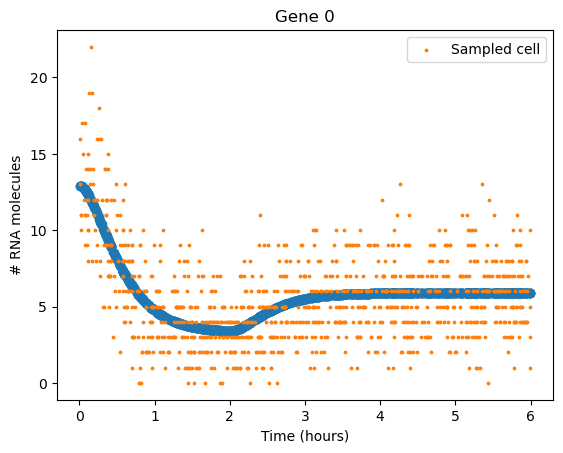

In [6]:
idx = 0

plt.scatter(true_t, Y[:, idx, 1]);
plt.scatter(true_t, Y_observed[:, idx, 1], s=3, label="Sampled cell");
plt.xlabel("Time (hours)");
plt.ylabel("# RNA molecules");
plt.title(f"Gene {idx}");
plt.legend();

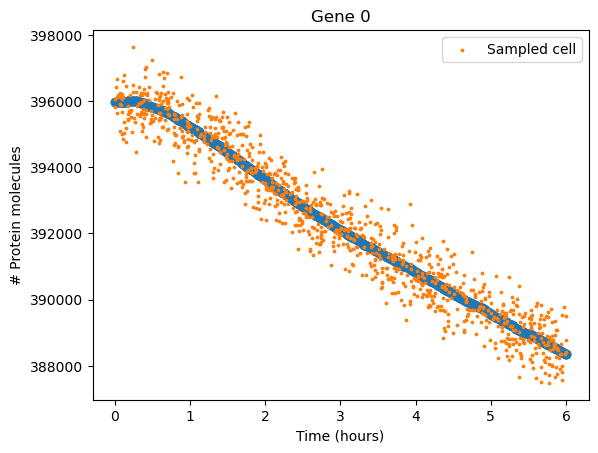

In [7]:
plt.scatter(true_t, P[:, idx]);
plt.scatter(true_t, P_observed[:, idx], s=3, label="Sampled cell");
plt.xlabel("Time (hours)");
plt.ylabel("# Protein molecules");
plt.title(f"Gene {idx}");
plt.legend();

# For a given gene:
## Calculate protein abundance from RNA levels using range of translation and protein degradation rates

In [8]:
# Now for each gene, sample a range of translation rates or degradation rates around true rate

n_resamples = 100
dispersion_factor = 1 # Smaller value = larger spread

In [9]:
P_sampled_transl_observed, P_sampled_transl, sampled_transl_rates = simulate_protein_transl_rate_sensitivity(Y_observed, topo, true_t, true_l, phi, dispersion_factor, n_resamples, random_seed=random_seed)
P_sampled_deg_observed, P_sampled_deg, sampled_deg_rates = simulate_protein_deg_rate_sensitivity(Y_observed, topo, true_t, true_l, phi, dispersion_factor, n_resamples, random_seed=random_seed)

In [15]:
sampled_transl_corrs = np.array([[np.corrcoef(P_sampled_transl[r, :, idx], 
                                              P[:, idx])[0, 1] for idx in range(p)] 
                                 for r in range(n_resamples)])

sampled_deg_corrs = np.array([[np.corrcoef(P_sampled_deg[r, :, idx], 
                                           P[:, idx])[0, 1] for idx in range(p)] 
                              for r in range(n_resamples)])

In [16]:
sampled_transl_errors = np.array([np.sqrt(np.mean((P_sampled_transl[:, :, idx] - P[None, :, idx])**2, axis=1)) for idx in range(p)])
sampled_deg_errors = np.array([np.sqrt(np.mean((P_sampled_deg[:, :, idx] - P[None, :, idx])**2, axis=1)) for idx in range(p)])

## Translation rate

In [157]:
gene_idx = 10

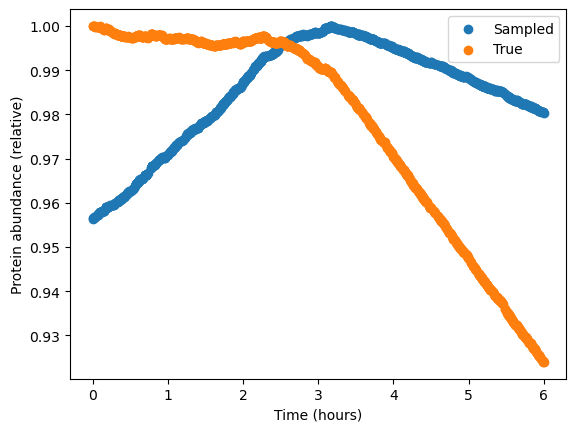

In [158]:
plt.scatter(true_t, 
            P_sampled_deg[0, :, gene_idx] / np.max(P_sampled_deg[0, :, gene_idx]), 
            label="Sampled")
plt.scatter(true_t, P[:, gene_idx] / np.max(P[:, gene_idx]), label="True");
plt.xlabel("Time (hours)");
plt.ylabel("Protein abundance (relative)");
plt.legend();

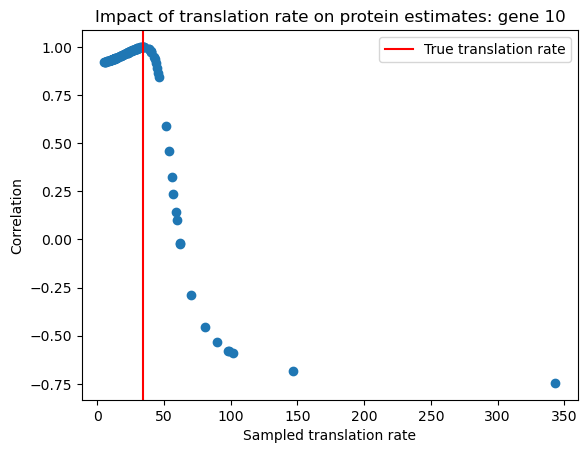

In [159]:
plt.scatter(sampled_transl_rates[gene_idx, :], sampled_transl_corrs[:, gene_idx]);
plt.axvline(x=phi[gene_idx, 0], color='red', label="True translation rate")
plt.xlabel("Sampled translation rate");
plt.ylabel("Correlation");
plt.title(f"Impact of translation rate on protein estimates: gene {gene_idx}");
plt.legend();

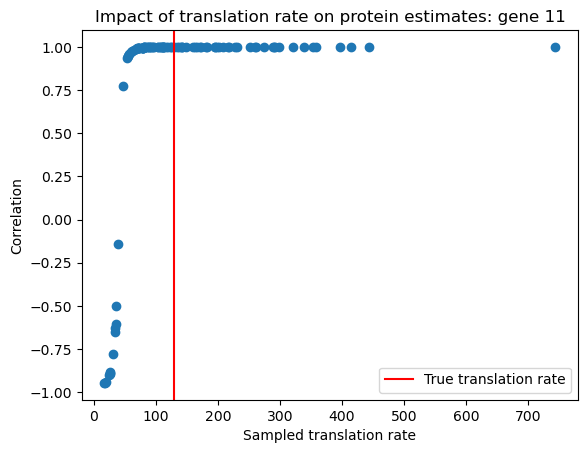

In [98]:
plt.scatter(sampled_transl_rates[11, :], sampled_transl_corrs[:, 11]);
plt.axvline(x=phi[11, 0], color='red', label="True translation rate")
plt.xlabel("Sampled translation rate");
plt.ylabel("Correlation");
plt.title(f"Impact of translation rate on protein estimates: gene {11}");
plt.legend();

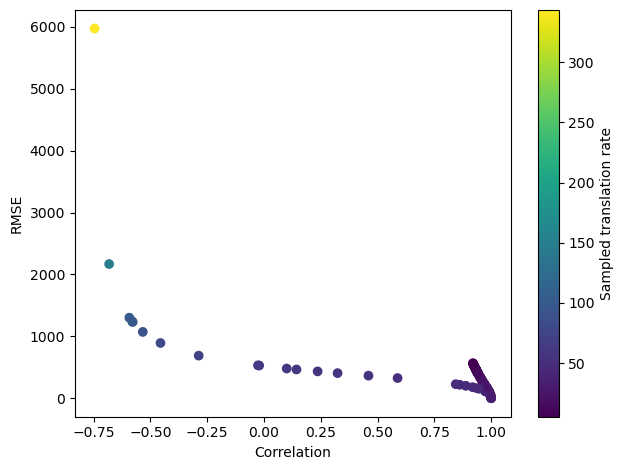

In [162]:
transl_rate_dev = sampled_transl_rates[gene_idx, :] - phi[gene_idx, 0]

fig, ax = plt.subplots()

sc = ax.scatter(
    sampled_transl_corrs[:, gene_idx],
    sampled_transl_errors[gene_idx, :],
    c=sampled_transl_rates[gene_idx, :]
)

ax.set_xlabel("Correlation")
ax.set_ylabel("RMSE")

cbar = fig.colorbar(sc, ax=ax)
cbar.set_label("Sampled translation rate") 

plt.tight_layout()
plt.show()

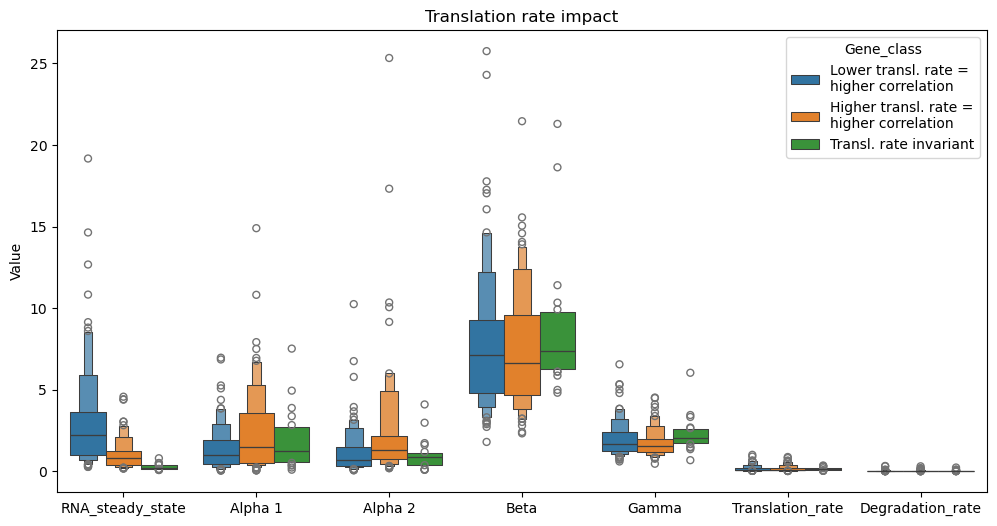

In [170]:
eps = 10e-10

rows = []
for gene_idx in range(p):
    
    RNA_steady_state = theta[gene_idx, 0]
    alpha_vals = theta[gene_idx, 1:-2]  # All columns after steady_state up to beta
    beta = theta[gene_idx, -2]
    gamma = theta[gene_idx, -1]

    min_sample_rate_idx = np.argmin(sampled_transl_rates[gene_idx, :])
    min_rate_cor = sampled_transl_corrs[min_sample_rate_idx, gene_idx]

    max_sample_rate_idx = np.argmax(sampled_transl_rates[gene_idx, :])
    max_rate_cor = sampled_transl_corrs[max_sample_rate_idx, gene_idx]

    dy = max_rate_cor - min_rate_cor
    dx = sampled_transl_rates[gene_idx, max_sample_rate_idx] - sampled_transl_rates[gene_idx, min_sample_rate_idx] 

    roc = dy/dx
    if roc > 0:
        gene_class = "Higher transl. rate =\nhigher correlation"
    else:
        gene_class = "Lower transl. rate =\nhigher correlation"
        
    if abs(roc) <= eps:
        gene_class = "Transl. rate invariant"

    row = {
        'Gene_class': gene_class,
        'Min_cor': np.min(np.mean(sampled_transl_corrs[:, gene_idx])),
        'Median_cor': np.median(sampled_transl_corrs[:, gene_idx]),
        'Max_cor': np.max(sampled_transl_corrs[:, gene_idx]),
        'RNA_steady_state': RNA_steady_state,
        'Beta': beta,
        'Gamma': gamma,
        'Translation_rate': phi[gene_idx, 0],
        'Degradation_rate': phi[gene_idx, -1]
    }
        
    for j, val in enumerate(alpha_vals, 1):
        row[f'Alpha {j}'] = val
        
    rows.append(row)
    
data = pd.DataFrame(rows)

data = pd.concat([data, pd.DataFrame(sampled_transl_corrs)], ignore_index=True)

# Normalize parameter values to make plot more interpretable
# data['RNA_steady_state'] = data['RNA_steady_state'] / np.max(data['RNA_steady_state'])
# data['Beta'] = data['Beta'] / np.max(data['Beta'])
# data['Gamma'] = data['Gamma'] / np.max(data['Gamma'])
# data['Alpha 1'] = data['Alpha 1'] / np.max(data['Alpha 1'])
# data['Alpha 2'] = data['Alpha 2'] / np.max(data['Alpha 2'])
data['Translation_rate'] = data['Translation_rate'] / np.max(data['Translation_rate'])
# data['Degradation_rate'] = data['Degradation_rate'] / np.max(data['Degradation_rate'])

data_long = data.melt(id_vars="Gene_class", 
                      value_vars=["RNA_steady_state", "Alpha 1", "Alpha 2", "Beta", "Gamma", "Translation_rate", "Degradation_rate"],
                      var_name="Kinetic_parameter", 
                      value_name="Value")
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.boxenplot(data=data_long, x="Kinetic_parameter", y="Value", hue="Gene_class")
plt.title("Translation rate impact")
plt.xlabel("") 
# plt.yscale("log", base=2)
plt.show()

## Degradation rate

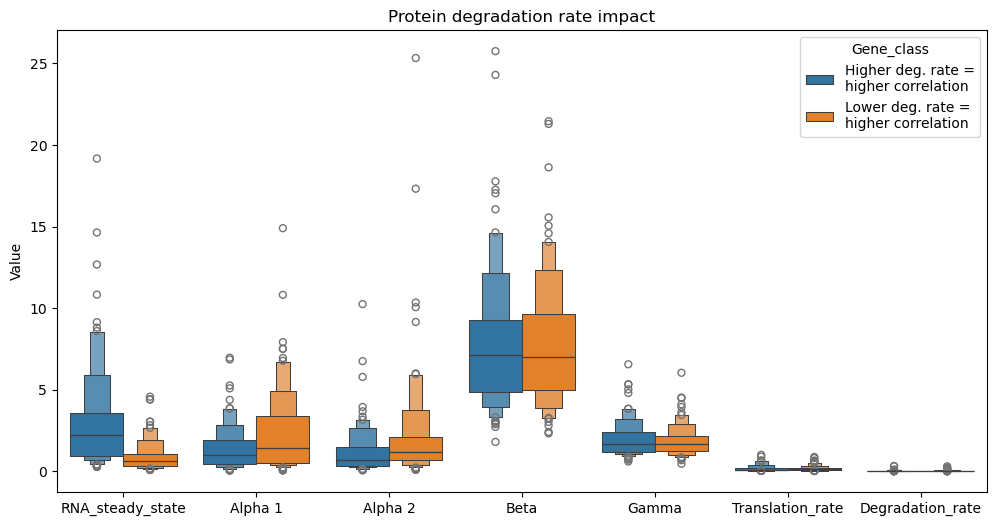

In [177]:
eps = 10e-5

rows = []
for gene_idx in range(p):
    
    RNA_steady_state = theta[gene_idx, 0]
    alpha_vals = theta[gene_idx, 1:-2]  # All columns after steady_state up to beta
    beta = theta[gene_idx, -2]
    gamma = theta[gene_idx, -1]

    min_sample_rate_idx = np.argmin(sampled_deg_rates[gene_idx, :])
    min_rate_cor = sampled_deg_corrs[min_sample_rate_idx, gene_idx]

    max_sample_rate_idx = np.argmax(sampled_deg_rates[gene_idx, :])
    max_rate_cor = sampled_deg_corrs[max_sample_rate_idx, gene_idx]

    dy = max_rate_cor - min_rate_cor
    dx = sampled_deg_rates[gene_idx, max_sample_rate_idx] - sampled_deg_rates[gene_idx, min_sample_rate_idx] 

    roc = dy/dx
    if roc > 0:
        gene_class = "Higher deg. rate =\nhigher correlation"
    else:
        gene_class = "Lower deg. rate =\nhigher correlation"
        
    if abs(roc) <= eps:
        gene_class = "deg. rate invariant"

    row = {
        'Gene_class': gene_class,
        'Min_cor': np.min(np.mean(sampled_deg_corrs[:, gene_idx])),
        'Median_cor': np.median(sampled_deg_corrs[:, gene_idx]),
        'Max_cor': np.max(sampled_deg_corrs[:, gene_idx]),
        'RNA_steady_state': RNA_steady_state,
        'Beta': beta,
        'Gamma': gamma,
        'Translation_rate': phi[gene_idx, 0],
        'Degradation_rate': phi[gene_idx, -1]
    }
        
    for j, val in enumerate(alpha_vals, 1):
        row[f'Alpha {j}'] = val
        
    rows.append(row)
    
data = pd.DataFrame(rows)

data = pd.concat([data, pd.DataFrame(sampled_deg_corrs)], ignore_index=True)

# Normalize parameter values to make plot more interpretable
# data['RNA_steady_state'] = data['RNA_steady_state'] / np.max(data['RNA_steady_state'])
# data['Beta'] = data['Beta'] / np.max(data['Beta'])
# data['Gamma'] = data['Gamma'] / np.max(data['Gamma'])
# data['Alpha 1'] = data['Alpha 1'] / np.max(data['Alpha 1'])
# data['Alpha 2'] = data['Alpha 2'] / np.max(data['Alpha 2'])
data['Translation_rate'] = data['Translation_rate'] / np.max(data['Translation_rate'])
# data['Degradation_rate'] = data['Degradation_rate'] / np.max(data['Degradation_rate'])

data_long = data.melt(id_vars="Gene_class", 
                      value_vars=["RNA_steady_state", "Alpha 1", "Alpha 2", "Beta", "Gamma", "Translation_rate", "Degradation_rate"],
                      var_name="Kinetic_parameter", 
                      value_name="Value")
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.boxenplot(data=data_long, x="Kinetic_parameter", y="Value", hue="Gene_class")
plt.title("Protein degradation rate impact")
plt.xlabel("") 
# plt.yscale("log", base=2)
plt.show()

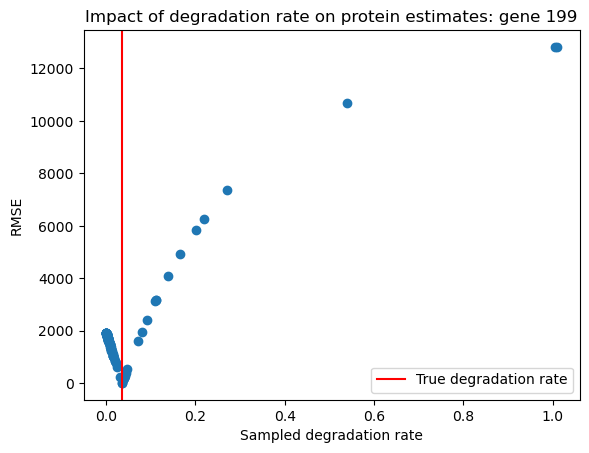

In [139]:
plt.scatter(sampled_deg_rates[gene_idx, :], sampled_deg_errors[gene_idx, :]);
plt.axvline(x=phi[gene_idx, -1], color='red', label="True degradation rate")
plt.xlabel("Sampled degradation rate");
plt.ylabel("RMSE");
plt.title(f"Impact of degradation rate on protein estimates: gene {gene_idx}");
plt.legend();

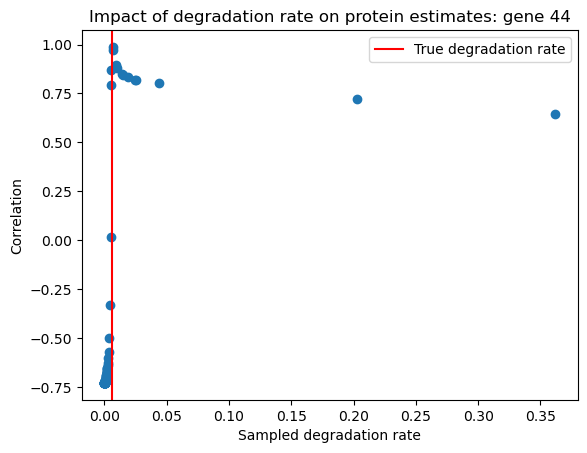

In [87]:
plt.scatter(sampled_deg_rates[gene_idx, :], sampled_deg_corrs[:, gene_idx]);
plt.axvline(x=phi[gene_idx, -1], color='red', label="True degradation rate")
plt.xlabel("Sampled degradation rate");
plt.ylabel("Correlation");
plt.title(f"Impact of degradation rate on protein estimates: gene {gene_idx}");
plt.legend();

In [58]:
# plt.scatter(sampled_deg_rates[gene_idx, :], sampled_deg_errors[gene_idx, :]);
# plt.axvline(x=phi[gene_idx, -1], color='red', label="True degradation rate")
# plt.xlabel("Sampled degradation rate");
# plt.ylabel("RMSE");
# plt.title(f"Impact of degradation rate on protein estimates: gene {gene_idx}");
# plt.legend();

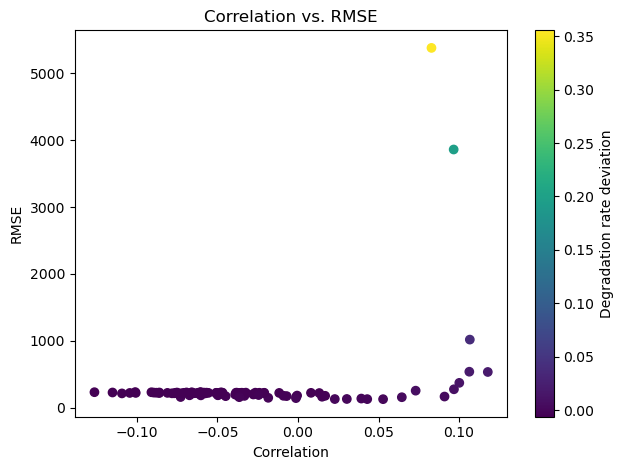

In [59]:
deg_rate_dev = sampled_deg_rates[gene_idx, :] - phi[gene_idx, -1]

fig, ax = plt.subplots()

sc = ax.scatter(
    sampled_deg_corrs[:, gene_idx],
    sampled_deg_errors[gene_idx, :],
    c=deg_rate_dev
)

ax.set_xlabel("Correlation")
ax.set_ylabel("RMSE")

cbar = fig.colorbar(sc, ax=ax)
cbar.set_label("Degradation rate deviation") 

plt.title("Correlation vs. RMSE");
plt.tight_layout()
plt.show()

In [83]:
diffs = sampled_deg_rates[gene_idx, :] - phi[gene_idx, -1]

valid_idx = np.where(diffs >= 0)[0]
out = valid_idx[diffs[valid_idx].argmin()]

max_deg_sample_idx = out


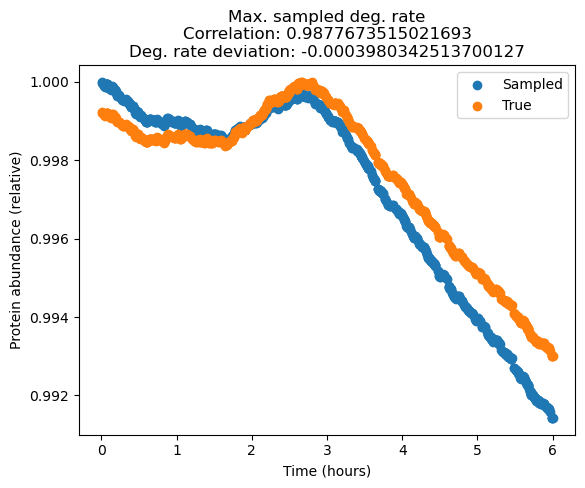

In [84]:

cor = np.corrcoef(P_sampled_deg[max_deg_sample_idx, :, gene_idx], P[:, gene_idx])[0, 1]
deg_dev = phi[gene_idx, -1] - sampled_deg_rates[gene_idx, max_deg_sample_idx]

plt.scatter(true_t, 
            P_sampled_deg[max_deg_sample_idx, :, gene_idx] / np.max(P_sampled_deg[max_deg_sample_idx, :, gene_idx]), 
            label="Sampled")
plt.scatter(true_t, P[:, gene_idx] / np.max(P[:, gene_idx]), label="True");
plt.title(f"Max. sampled deg. rate\nCorrelation: {cor}\nDeg. rate deviation: {deg_dev}");
plt.xlabel("Time (hours)");
plt.ylabel("Protein abundance (relative)");
plt.legend();

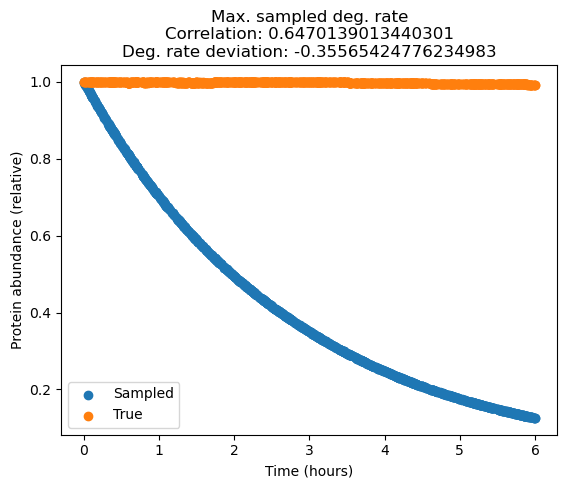

In [88]:
max_deg_sample_idx = np.argmax(sampled_deg_rates[gene_idx, :])
cor = np.corrcoef(P_sampled_deg[max_deg_sample_idx, :, gene_idx], P[:, gene_idx])[0, 1]
deg_dev = phi[gene_idx, -1] - sampled_deg_rates[gene_idx, max_deg_sample_idx]

plt.scatter(true_t, 
            P_sampled_deg[max_deg_sample_idx, :, gene_idx] / np.max(P_sampled_deg[max_deg_sample_idx, :, gene_idx]), 
            label="Sampled")
plt.scatter(true_t, P[:, gene_idx] / np.max(P[:, gene_idx]), label="True");
plt.title(f"Max. sampled deg. rate\nCorrelation: {cor}\nDeg. rate deviation: {deg_dev}");
plt.xlabel("Time (hours)");
plt.ylabel("Protein abundance (relative)");
plt.legend();

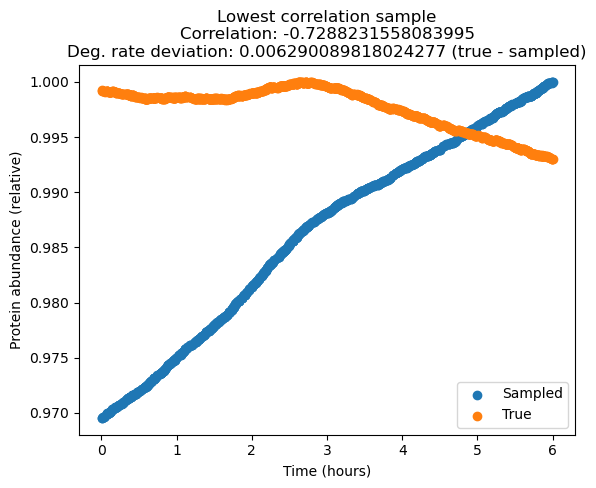

In [89]:
min_cor_sample_idx = np.argmin(sampled_deg_corrs[:, gene_idx])
cor = np.corrcoef(P_sampled_deg[min_cor_sample_idx, :, gene_idx], P[:, gene_idx])[0, 1]
deg_dev = phi[gene_idx, -1] - sampled_deg_rates[gene_idx, min_cor_sample_idx]

plt.scatter(true_t, 
            P_sampled_deg[min_cor_sample_idx, :, gene_idx] / np.max(P_sampled_deg[min_cor_sample_idx, :, gene_idx]), 
            label="Sampled")
plt.scatter(true_t, P[:, gene_idx] / np.max(P[:, gene_idx]), label="True");
plt.title(f"Lowest correlation sample\nCorrelation: {cor}\nDeg. rate deviation: {deg_dev} (true - sampled)");
plt.xlabel("Time (hours)");
plt.ylabel("Protein abundance (relative)");
plt.legend();

In [20]:
# Summarize this information for all genes

In [90]:
transl_devs = np.array([sampled_transl_rates[gene_idx, :] - phi[gene_idx, 0] for gene_idx in range(p)])
deg_devs = np.array([sampled_deg_rates[gene_idx, :] - phi[gene_idx, -1] for gene_idx in range(p)])

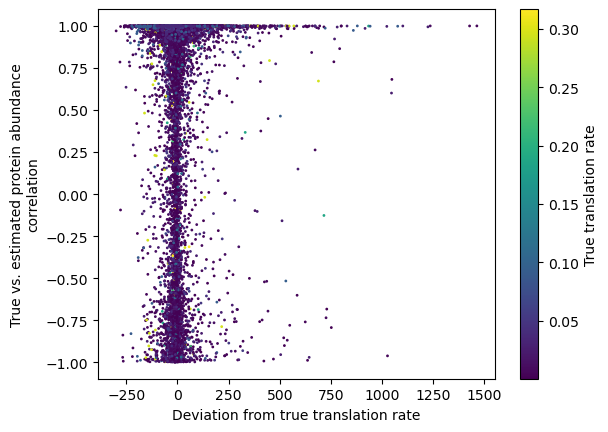

In [ ]:
c = np.repeat(phi[:, 0], sampled_transl_rates.shape[1], axis=0)


sc = plt.scatter(transl_devs, sampled_transl_corrs.flatten(), s=1, c=c, cmap="viridis");
plt.xlabel("Deviation from true translation rate");
plt.ylabel("True vs. estimated protein abundance\ncorrelation");

cb = plt.colorbar(sc)
cb.set_label("True translation rate")
plt.show()


Text(0, 0.5, 'True vs. estimated protein abundance\ncorrelation')

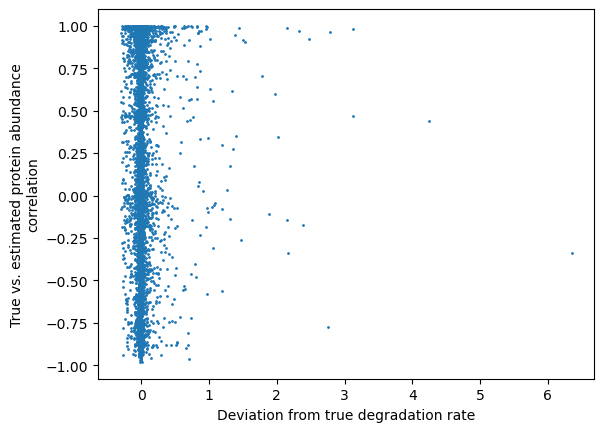

In [40]:
plt.scatter(deg_devs, sampled_deg_corrs.flatten(), s=1);
plt.xlabel("Deviation from true degradation rate");
plt.ylabel("True vs. estimated protein abundance\ncorrelation")

(array([ 193.,  351.,  466.,  654., 1877., 2813., 1617., 1990., 2484.,
        7555.]),
 array([-0.94939781, -0.75450701, -0.55961621, -0.3647254 , -0.1698346 ,
         0.0250562 ,  0.219947  ,  0.41483781,  0.60972861,  0.80461941,
         0.99951021]),
 <BarContainer object of 10 artists>)

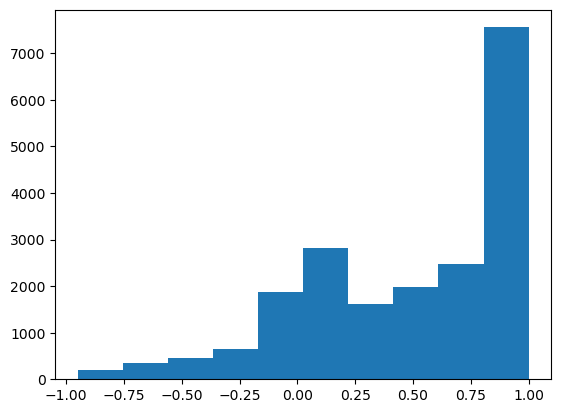

In [ ]:
plt.hist()

(array([ 982., 1216., 1360., 1373., 2841., 1483., 1192., 1536., 1844.,
        6173.]),
 array([-0.98085074, -0.78281907, -0.5847874 , -0.38675573, -0.18872406,
         0.00930761,  0.20733928,  0.40537095,  0.60340262,  0.80143429,
         0.99946596]),
 <BarContainer object of 10 artists>)

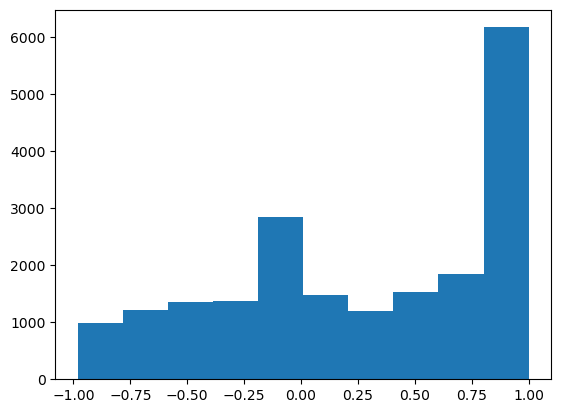

In [34]:
plt.hist(sampled_deg_corrs.flatten())

In [ ]:
cor_vs_rmse = [np.corrcoef(sampled_deg_corrs[:, gene_idx], sampled_deg_errors[gene_idx, :])[0, 1] for gene_idx in range(p)]

# For a given cell (Poisson sampled):
## Calculate its RNA history for each gene using: cell starting counts, and kinetic parameters (known) and recursive equation for expected # unspliced and spliced counts
